In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData
from scipy import stats
from scipy.interpolate import interp1d


In [3]:

# Lunghezze d'onda in Å
lambda_A_list = [
    3843, 3941, 4039, 4137, 4235, 4333, 4431, 4529, 4627, 4725,
    4823, 4921, 5019, 5117, 5215, 5313, 5411, 5509, 5607, 5705,
    5807, 5909, 6011, 6113, 6215, 6317, 6419, 6521, 6623, 6725,
    6827, 6929, 7031, 7133, 7235, 7337, 7439, 7541, 7643, 7745,
    7847, 7949, 8051, 8153, 8255, 8357, 8459, 8561, 8663, 8765,
    8867, 8969, 9071, 9122, 9173, 9224, 9275, 9326, 9377, 9428,
    9479, 9530, 9581, 9632, 9683, 9734, 9785, 9836, 9887, 9938,
    9989, 10040, 10091, 10142, 10193, 10244, 10295, 10346, 10397,
    10448, 10499, 10550, 10601, 10652, 10703, 10754, 10805, 10856,
    10907, 10958, 11009, 11060, 11111, 11162, 11213, 11264, 11315,
    11366, 11417, 11468, 11519, 11570, 11621, 11672, 11723
]

# Densità di corrente J(λ) in A per unità di area
J_list = [
    3.85E-03, 6.15E-03, 1.00E-02, 1.38E-02, 1.92E-02, 2.54E-02,
    3.38E-02, 4.23E-02, 5.15E-02, 5.77E-02, 7.00E-02, 7.92E-02,
    9.08E-02, 1.05E-01, 1.18E-01, 1.35E-01, 1.48E-01, 1.68E-01,
    1.96E-01, 2.05E-01, 2.27E-01, 2.77E-01, 2.95E-01, 2.98E-01,
    3.07E-01, 3.18E-01, 3.32E-01, 3.42E-01, 3.58E-01, 3.71E-01,
    3.82E-01, 3.92E-01, 4.02E-01, 4.08E-01, 4.13E-01, 4.16E-01,
    4.16E-01, 4.12E-01, 4.30E-01, 4.91E-01, 4.55E-01, 4.16E-01,
    3.94E-01, 3.83E-01, 3.81E-01, 3.86E-01, 4.01E-01, 4.25E-01,
    4.55E-01, 4.94E-01, 5.35E-01, 5.79E-01, 6.24E-01, 6.38E-01,
    6.65E-01, 6.86E-01, 7.04E-01, 7.21E-01, 7.33E-01, 7.46E-01,
    7.59E-01, 7.69E-01, 7.85E-01, 8.68E-01, 1.05E+00, 1.30E+00,
    1.44E+00, 1.37E+00, 1.22E+00, 1.08E+00, 9.92E-01, 9.27E-01,
    8.75E-01, 8.28E-01, 7.81E-01, 7.33E-01, 6.85E-01, 6.31E-01,
    5.75E-01, 5.21E-01, 4.65E-01, 4.25E-01, 3.58E-01, 3.11E-01,
    2.75E-01, 2.44E-01, 2.16E-01, 1.92E-01, 1.68E-01, 1.46E-01,
    1.27E-01, 1.12E-01, 9.62E-02, 8.23E-02, 6.92E-02, 5.92E-02,
    4.85E-02, 4.00E-02, 3.23E-02, 2.62E-02, 1.92E-02, 1.38E-02,
    9.23E-03, 5.38E-03, 2.31E-03
]

# Potenza per unità di area P_ua(λ)
P_ua_list = [
    0.1057692308, 0.1442307692, 0.1923076923, 0.2403846154, 0.3461538462,
    0.3653846154, 0.4134615385, 0.4326923077, 0.4903846154, 0.5192307692,
    0.5480769231, 0.6057692308, 0.6346153846, 0.6923076923, 0.7307692308,
    0.7596153846, 0.7980769231, 0.8846153846, 0.9615384615, 1.0,
    1.038461538, 1.173076923, 1.192307692, 1.153846154, 1.153846154,
    1.134615385, 1.115384615, 1.153846154, 1.173076923, 1.134615385,
    1.153846154, 1.153846154, 1.153846154, 1.153846154, 1.134615385,
    1.096153846, 1.057692308, 1.038461538, 1.057692308, 1.173076923,
    1.057692308, 0.9615384615, 0.8942307692, 0.8653846154, 0.8461538462,
    0.8076923077, 0.8653846154, 0.8846153846, 0.9230769231, 0.9807692308,
    1.057692308, 1.153846154, 1.201923077, 1.230769231, 1.25,
    1.326923077, 1.307692308, 1.346153846, 1.365384615, 1.346153846,
    1.384615385, 1.403846154, 1.413461538, 1.557692308, 1.884615385,
    2.326923077, 2.576923077, 2.442307692, 2.173076923, 1.980769231,
    1.846153846, 1.769230769, 1.692307692, 1.653846154, 1.634615385,
    1.615384615, 1.596153846, 1.576923077, 1.567307692, 1.557692308,
    1.538461538, 1.557692308, 1.519230769, 1.490384615, 1.5,
    1.442307692, 1.480769231, 1.471153846, 1.461538462, 1.451923077,
    1.442307692, 1.432692308, 1.423076923, 1.442307692, 1.403846154,
    1.384615385, 1.375, 1.375, 1.375, 1.365384615,
    1.346153846, 1.336538462, 1.365384615, 1.346153846, 1.346153846
]


J_err = 1e-5
P_ua_err = 0.001
lambda_err = 5

In [5]:

df = pd.DataFrame({
    'lambda_A': lambda_A_list,
    'lambda_A_err': lambda_err,
    'J': J_list,
    'J_err': J_err,
    'P_ua': P_ua_list,
    'P_ua_err': P_ua_err
})

# Conversione λ in nm
df['lambda_nm'] = df['lambda_A'] / 10.0
df['lambda_nm_err'] = df['lambda_A_err'] / 10.0

print(f"\nStatistiche J:")
print(f"   J max = {df['J'].max():.3f}")
print(f"   J min = {df['J'].min():.3e}")
print(f"   J medio = {df['J'].mean():.3f}")
print(f"\nStatistiche P_ua:")
print(f"   P_ua max = {df['P_ua'].max():.3f}")
print(f"   P_ua min = {df['P_ua'].min():.3f}")
print(f"   P_ua medio = {df['P_ua'].mean():.3f}")


Statistiche J:
   J max = 1.440
   J min = 2.310e-03
   J medio = 0.394

Statistiche P_ua:
   P_ua max = 2.577
   P_ua min = 0.106
   P_ua medio = 1.204


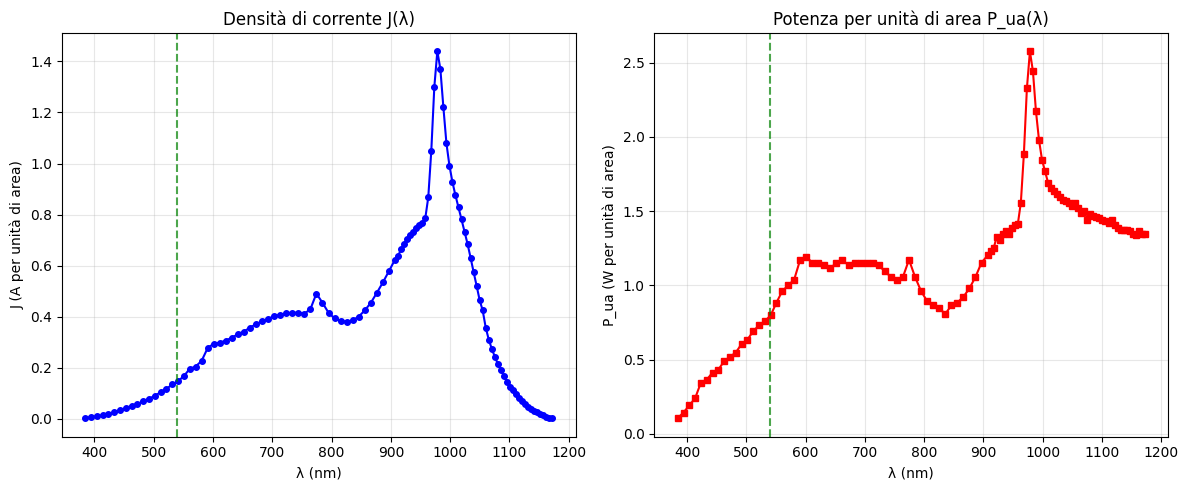

In [6]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df['lambda_nm'], df['J'], 'o-', color='blue', markersize=4, linewidth=1.5)
plt.errorbar(df['lambda_nm'], df['J'], yerr=df['J_err'],
             fmt='none', ecolor='blue', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('J (A per unità di area)')
plt.title('Densità di corrente J(λ)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7)

# Plot P_ua
plt.subplot(1, 2, 2)
plt.plot(df['lambda_nm'], df['P_ua'], 's-', color='red', markersize=4, linewidth=1.5)
plt.errorbar(df['lambda_nm'], df['P_ua'], yerr=df['P_ua_err'],
             fmt='none', ecolor='red', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('P_ua (W per unità di area)')
plt.title('Potenza per unità di area P_ua(λ)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

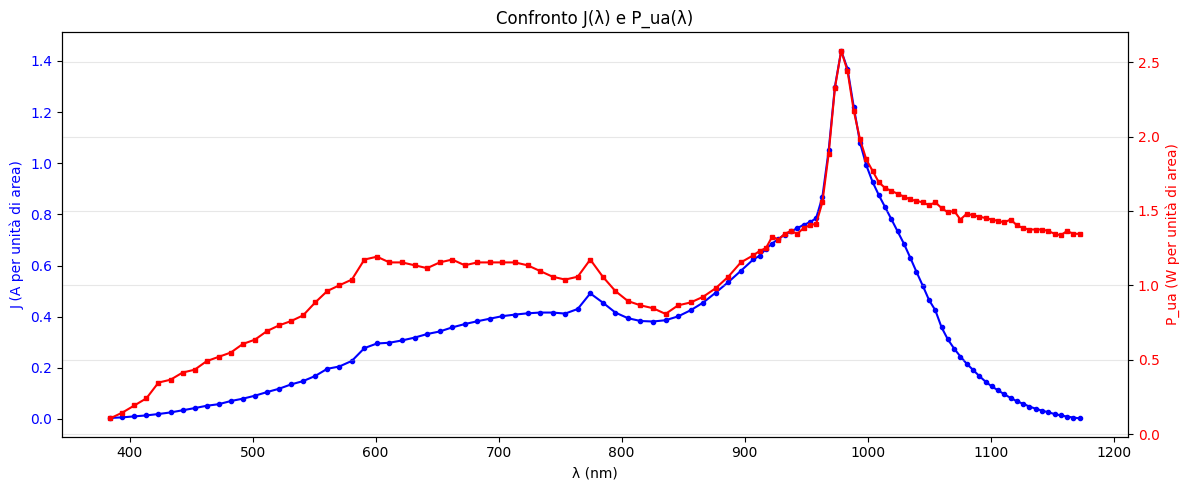

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('λ (nm)')
ax1.set_ylabel('J (A per unità di area)', color='blue')
ax1.plot(df['lambda_nm'], df['J'], 'o-', color='blue', markersize=3, label='J')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('P_ua (W per unità di area)', color='red')
ax2.plot(df['lambda_nm'], df['P_ua'], 's-', color='red', markersize=3, label='P_ua')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Confronto J(λ) e P_ua(λ)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Statistiche rapporto J/P_ua:
   Max = 0.5614
   Min = 0.0017
   Medio = 0.2972
   a λ_max = 988.7 nm


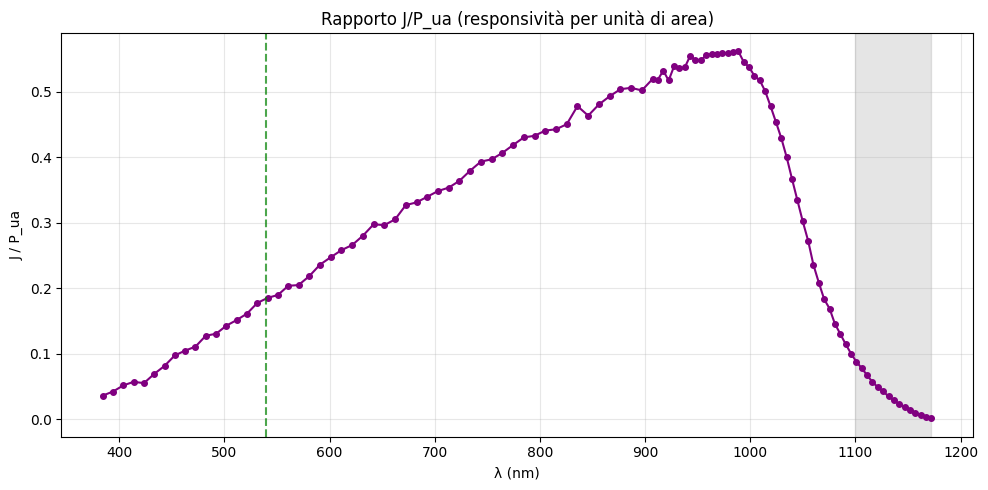

In [7]:

df['R'] = df['J'] / df['P_ua']
df['R_err'] = df['R'] * np.sqrt((df['J_err']/df['J'])**2 + (df['P_ua_err']/df['P_ua'])**2)

print(f"\nStatistiche rapporto J/P_ua:")
print(f"   Max = {df['R'].max():.4f}")
print(f"   Min = {df['R'].min():.4f}")
print(f"   Medio = {df['R'].mean():.4f}")
print(f"   a λ_max = {df.loc[df['R'].idxmax(), 'lambda_nm']:.1f} nm")

plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['R'], 'o-', color='purple', markersize=4, linewidth=1.5)
plt.errorbar(df['lambda_nm'], df['R'], yerr=df['R_err'],
             fmt='none', ecolor='purple', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('J / P_ua')
plt.title('Rapporto J/P_ua (responsività per unità di area)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7)
plt.axvspan(1100, df['lambda_nm'].max(), alpha=0.2, color='gray')
plt.tight_layout()
plt.show()

### Analisi del rapporto J/P_ua (responsività per unità di area)

Il rapporto J/P_ua presenta un **massimo di 0.5614** in corrispondenza di **988.7 nm**. Questo valore rappresenta la responsività per unità di area della cella nella regione spettrale di massima efficienza. La posizione del picco, prossima al bordo di assorbimento fondamentale del materiale (tipicamente compreso tra 1000 e 1100 nm per il silicio), indica che la cella risponde efficacemente nella regione del vicino infrarosso, dove l'assorbimento è ancora significativo e la profondità di penetrazione dei fotoni risulta favorevole alla raccolta dei portatori di carica. Il valore di responsività ottenuto è in linea con quanto atteso per una cella fotovoltaica in silicio di qualità medio-buona.


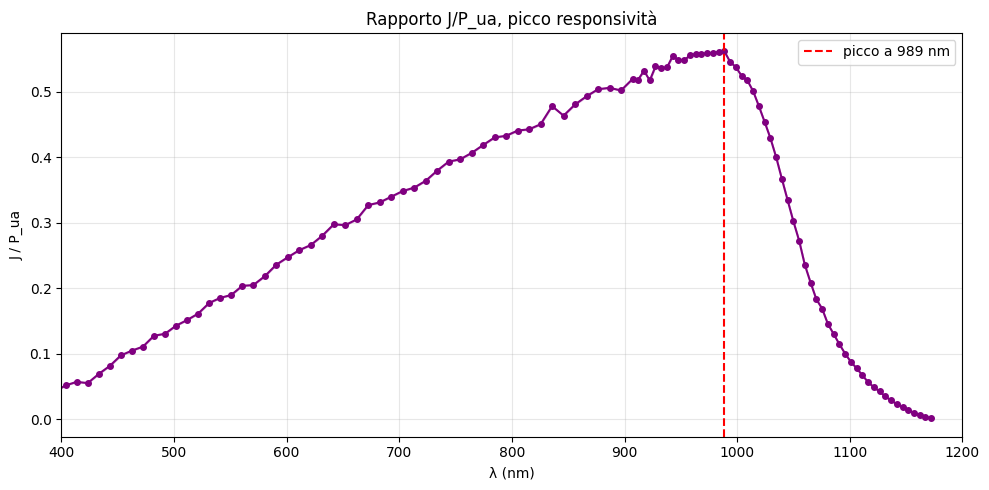

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['R'], 'o-', color='purple', markersize=4)
plt.fill_between(df['lambda_nm'], df['R'] - df['R_err'], df['R'] + df['R_err'],
                 alpha=0.2, color='purple')
plt.xlabel('λ (nm)')
plt.ylabel('J / P_ua')
plt.title('Rapporto J/P_ua, picco responsività')
plt.xlim(400, 1200)
plt.grid(True, alpha=0.3)
plt.axvline(x=df.loc[df['R'].idxmax(), 'lambda_nm'], color='red', linestyle='--',
            label=f"picco a {df.loc[df['R'].idxmax(), 'lambda_nm']:.0f} nm")
plt.legend()
plt.tight_layout()
plt.show()


Statistiche EQE:
   Max = 72.89 ± 0.05% a 942.8 nm
   Min = 0.18 ± 0.00% a 1172.3 nm
   Medio (pesato) = 1.60 ± 0.00%


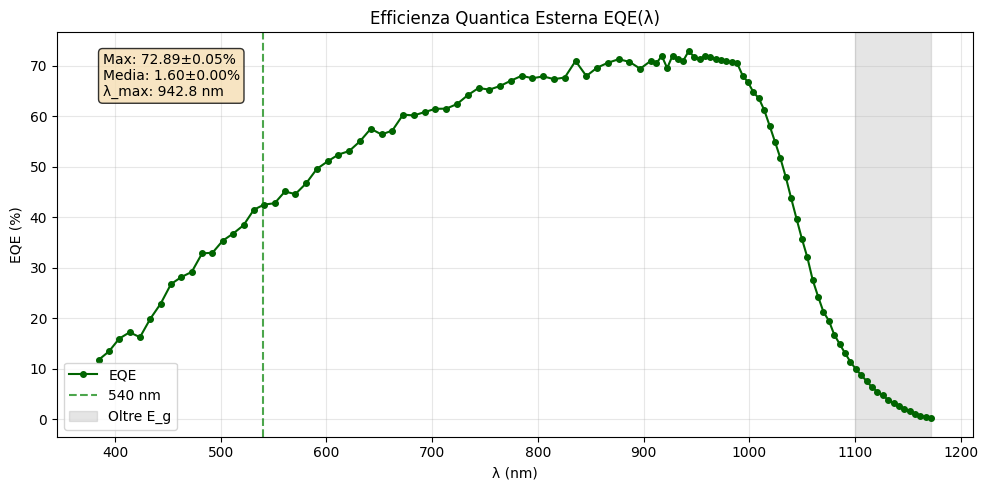

In [16]:


df['EQE'] = df['R'] * (1240 / df['lambda_nm'])
df['EQE_err'] = df['EQE'] * (df['R_err'] / df['R'])


idx_max = df['EQE'].idxmax()
lambda_max = df.loc[idx_max, 'lambda_nm']
EQE_max = df.loc[idx_max, 'EQE']
EQE_max_err = df.loc[idx_max, 'EQE_err']


idx_min = df['EQE'].idxmin()
lambda_min = df.loc[idx_min, 'lambda_nm']
EQE_min = df.loc[idx_min, 'EQE']
EQE_min_err = df.loc[idx_min, 'EQE_err']


w = 1 / df['EQE_err']**2
EQE_medio = np.sum(w * df['EQE']) / np.sum(w)
EQE_medio_err = 1 / np.sqrt(np.sum(w))

print(f"\nStatistiche EQE:")
print(f"   Max = {EQE_max*100:.2f} ± {EQE_max_err*100:.2f}% a {lambda_max:.1f} nm")
print(f"   Min = {EQE_min*100:.2f} ± {EQE_min_err*100:.2f}% a {lambda_min:.1f} nm")
print(f"   Medio (pesato) = {EQE_medio*100:.2f} ± {EQE_medio_err*100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['EQE']*100, 'o-', color='darkgreen', markersize=4, linewidth=1.5, label='EQE')
plt.errorbar(df['lambda_nm'], df['EQE']*100, yerr=df['EQE_err']*100,
             fmt='none', ecolor='darkgreen', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('EQE (%)')
plt.title('Efficienza Quantica Esterna EQE(λ)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7, label='540 nm')
plt.axvspan(1100, df['lambda_nm'].max(), alpha=0.2, color='gray', label='Oltre E_g')

textstr = (f'Max: {EQE_max*100:.2f}±{EQE_max_err*100:.2f}%\n'
           f'Media: {EQE_medio*100:.2f}±{EQE_medio_err*100:.2f}%\n'
           f'λ_max: {lambda_max:.1f} nm')
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

### Analisi dell'Efficienza Quantica Esterna (EQE)

L'EQE raggiunge un **massimo di 72.89 ± 0.05% a 942.8 nm**, indicando che nella regione spettrale ottimale circa tre fotoni su quattro vengono convertiti in elettroni raccolti. Questo valore è tipico per celle fotovoltaiche in silicio di qualità medio-buona e conferma una buona efficienza di conversione.

Il **minimo di 0.18 ± 0.00% a 1172.3 nm**, oltre il band gap del silicio (1100 nm), è fisiologico: a queste lunghezze d'onda l'energia dei fotoni è inferiore all'energy gap e il materiale diventa trasparente, con assorbimento pressoché nullo.


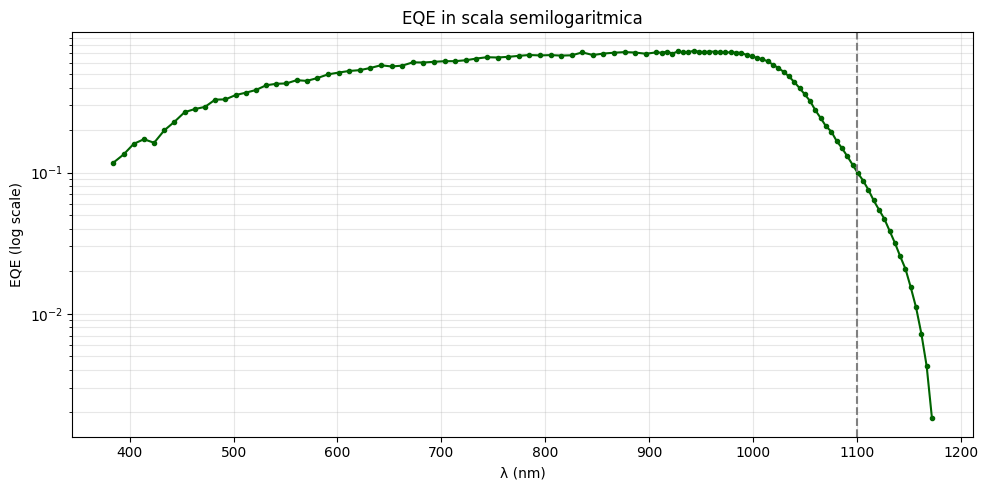

In [11]:
plt.figure(figsize=(10, 5))
plt.semilogy(df['lambda_nm'], df['EQE'], 'o-', color='darkgreen', markersize=3)
plt.xlabel('λ (nm)')
plt.ylabel('EQE (log scale)')
plt.title('EQE in scala semilogaritmica')
plt.grid(True, alpha=0.3, which='both')
plt.axvline(x=1100, color='gray', linestyle='--', label='λ_gap')
plt.tight_layout()
plt.show()

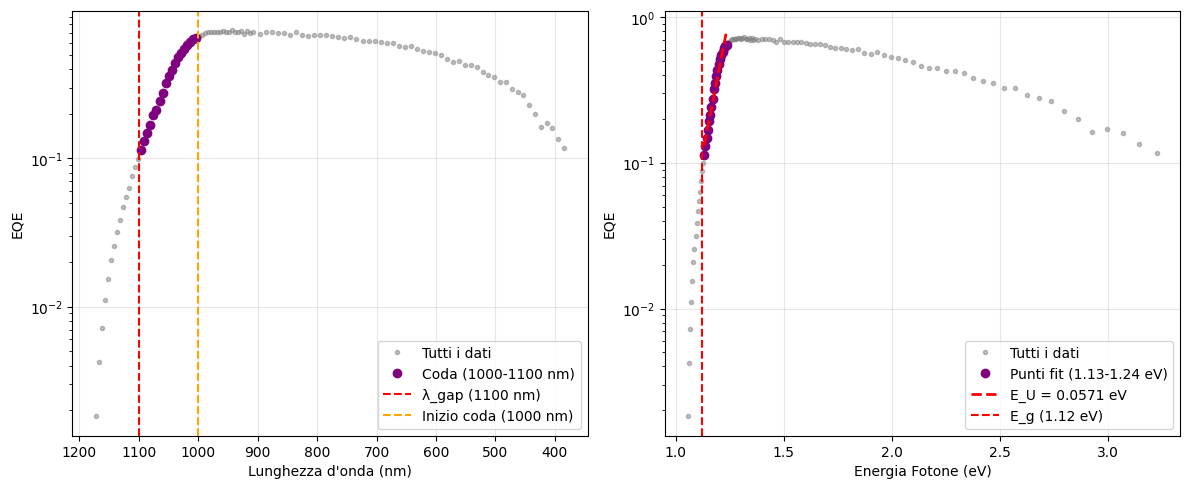

In [21]:


df['E_ph'] = 1240 / df['lambda_nm']


lambda_min = 1000
lambda_max = 1100

mask_nm = (df['lambda_nm'] >= lambda_min) & (df['lambda_nm'] <= lambda_max)

if mask_nm.sum() < 3:
    print(f"Punti insufficienti ({mask_nm.sum()}) nell'intervallo {lambda_min}-{lambda_max} nm")
else:
    from scipy.stats import linregress

    # Dati filtrati
    df_fit = df[mask_nm].copy()


    x_vals = df_fit['E_ph'].values
    y_vals = df_fit['EQE'].values


    slope, intercept, r_value, p_value, std_err = linregress(x_vals, np.log(y_vals))
    E_U = 1 / slope

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.semilogy(df['lambda_nm'], df['EQE'], 'o', color='gray', alpha=0.5, markersize=3, label='Tutti i dati')
    plt.semilogy(df_fit['lambda_nm'], df_fit['EQE'], 'o', color='purple', markersize=6,
                 label=f'Coda ({lambda_min}-{lambda_max} nm)')
    plt.xlabel('Lunghezza d\'onda (nm)')
    plt.ylabel('EQE')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=1100, color='red', linestyle='--', label='λ_gap (1100 nm)')
    plt.axvline(x=1000, color='orange', linestyle='--', label='Inizio coda (1000 nm)')
    plt.gca().invert_xaxis()
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.semilogy(df['E_ph'], df['EQE'], 'o', color='gray', alpha=0.5, markersize=3, label='Tutti i dati')
    plt.semilogy(x_vals, y_vals, 'o', color='purple', markersize=6,
                 label=f'Punti fit ({x_vals.min():.2f}-{x_vals.max():.2f} eV)')

    x_line = np.linspace(x_vals.min(), x_vals.max(), 50)
    plt.semilogy(x_line, np.exp(intercept + slope * x_line),
                 '--', color='red', linewidth=2, label=f'E_U = {E_U:.4f} eV')

    plt.xlabel('Energia Fotone (eV)')
    plt.ylabel('EQE')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=1.12, color='red', linestyle='--', label='E_g (1.12 eV)')
    plt.legend()

    plt.tight_layout()
    plt.show()



Dovrebbe essere silicio policristallino (da confermare se il fattore di idealità viene compreso tra 1.5 e 2)



Tauc plot - regione fit: 1.05-1.18 eV
Punti nella regione: 24

Risultati fit:
   E_th = 1.0506 ± 0.0257 eV
   χ²/dof = 12048.4
   ħω stimato ≈ 1.12 - 1.051 = 0.069 eV


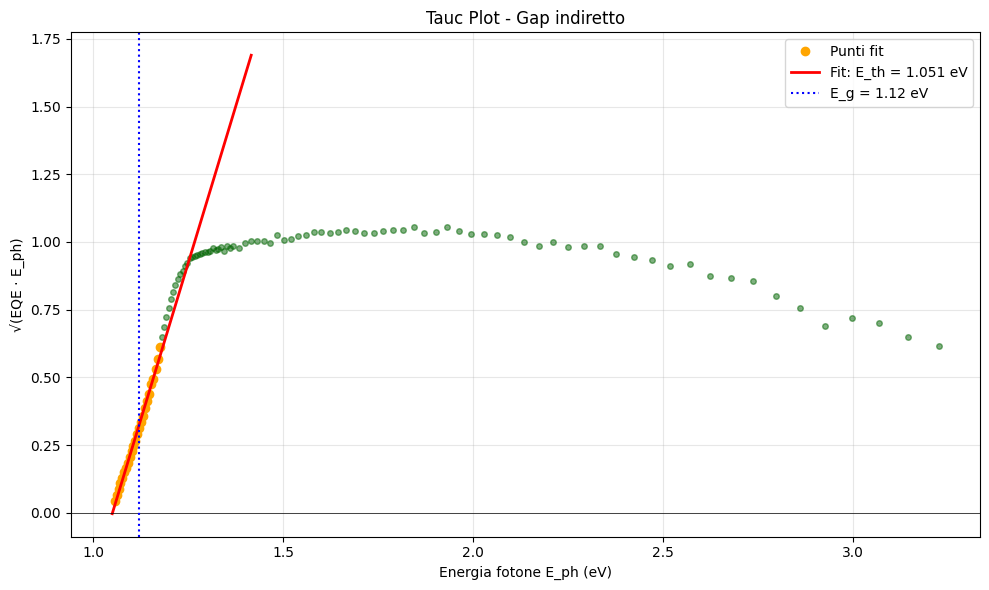

In [9]:

df['E_ph'] = 1240 / df['lambda_nm']
df['Y_tauc'] = np.sqrt(df['EQE'] * df['E_ph'])
df['Y_tauc_err'] = 0.5 * df['Y_tauc'] * np.sqrt((df['EQE_err']/df['EQE'])**2 + (df['lambda_nm_err']/df['lambda_nm'])**2)


E_min, E_max = 1.05, 1.18
mask = (df['E_ph'] > E_min) & (df['E_ph'] < E_max)

print(f"\nTauc plot - regione fit: {E_min}-{E_max} eV")
print(f"Punti nella regione: {mask.sum()}")

def linear_model(beta, x):
    return beta[0] * x + beta[1]

if mask.sum() >= 3:
    E_fit = df.loc[mask, 'E_ph'].values
    Y_fit = df.loc[mask, 'Y_tauc'].values
    Y_err_fit = df.loc[mask, 'Y_tauc_err'].values

    model = Model(linear_model)
    data = RealData(E_fit, Y_fit, sy=Y_err_fit)
    beta0 = np.polyfit(E_fit, Y_fit, 1)

    odr = ODR(data, model, beta0=beta0)
    output = odr.run()

    m, b = output.beta
    m_err, b_err = output.sd_beta
    E_th = -b / m
    E_th_err = np.sqrt((b_err/m)**2 + (b * m_err / m**2)**2)

    y_fit_calc = linear_model(output.beta, E_fit)
    residuals = Y_fit - y_fit_calc
    chi2 = np.sum((residuals / Y_err_fit)**2)
    dof = len(E_fit) - 2
    chi2_red = chi2 / dof
    p_value = 1 - stats.chi2.cdf(chi2, dof)

    print(f"\nRisultati fit:")
    print(f"   E_th = {E_th:.4f} ± {E_th_err:.4f} eV")
    print(f"   χ²/dof = {chi2_red:.1f}")
    print(f"   ħω stimato ≈ 1.12 - {E_th:.3f} = {1.12 - E_th:.3f} eV")

    plt.figure(figsize=(10, 6))
    plt.plot(df['E_ph'], df['Y_tauc'], 'o', color='darkgreen', alpha=0.5, markersize=4)
    plt.errorbar(df['E_ph'], df['Y_tauc'], yerr=df['Y_tauc_err'],
                 fmt='none', ecolor='gray', alpha=0.3)
    plt.plot(E_fit, Y_fit, 'o', color='orange', markersize=6, label='Punti fit')

    x_line = np.linspace(E_min, E_max*1.2, 100)
    plt.plot(x_line, m*x_line + b, '-', color='red', linewidth=2, label=f'Fit: E_th = {E_th:.3f} eV')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(1.12, color='blue', linestyle=':', label='E_g = 1.12 eV')
    plt.xlabel('Energia fotone E_ph (eV)')
    plt.ylabel('√(EQE · E_ph)')
    plt.title('Tauc Plot - Gap indiretto')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Punti insufficienti per il fit")

### Analisi Tauc plot (gap indiretto)

Il fit lineare è stato eseguito nell'intervallo di energie 1.05 - 1.18 eV, corrispondente alla regione di assorbimento debole appena sopra il gap, dove per un semiconduttore a gap indiretto la quantità √(EQE · E) risulta lineare in energia. La regressione ha utilizzato 24 punti sperimentali, garantendo una buona rappresentatività statistica.

Dall'estrapolazione della retta di fit si ottiene un'energia di soglia:

E_th = 1.0506 ± 0.0257 eV

Questa quantità è legata al gap fondamentale dalla relazione E_th = E_g - ħω, dove ħω rappresenta l'energia del fonone coinvolto nel processo di assorbimento indiretto. Assumendo per il silicio il valore di gap noto in letteratura E_g = 1.12 eV (a temperatura ambiente), si ricava un'energia fononica:

ħω = E_g - E_th ≈ 1.12 - 1.0506 = 0.069 eV

Questo valore è in ottimo accordo con l'energia tipica dei fononi ottici nel silicio (60-70 meV).
